In [1]:
pip install pandas numpy matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
## Netflix Movies and TV Shows Data Analysis
#Exploratory Data Analysis of Netflix content using Python and Pandas.

In [3]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")
#Understand your data
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
#The dataset contains information about Netflix movies and TV shows including title, director, cast, country, release year, and genre.

In [5]:
df.shape

(8807, 12)

In [6]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [7]:
#head() → shows first 5 rows
#• shape → tells (rows, columns)
#• columns → shows column names
#• info() → shows data types + missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
#Step2 check mssing values
df.isnull().sum()
#This shows missing values in each column.

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [9]:
#Step 3 check movies v/s Tv shows
df['type'].value_counts()
#This will show how many Movies and TV Shows.

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [10]:
#Step 4 Data cleaning
#Remove duplicate rows
df.duplicated().sum()

np.int64(0)

In [11]:
#Handle missing values
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown")
df['country'] = df['country'].fillna("Unknown")

In [10]:
#For small missing values:
df = df.dropna(subset=['date_added','rating','duration'])

In [11]:
df.isnull().sum()
#Why We Did This
#Big missing columns → fill with "Unknown"
#Very small missing rows → remove them

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [12]:
#STEP 5: First Real Analysis Question
#Which country produces the most content?
df['country'].value_counts().head(10)

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [13]:
#The United States dominates Netflix content production with over 2800 titles, followed by India with around 970 titles. This suggests Netflix heavily invests in the US and Indian markets. A significant number of records also have missing country information.

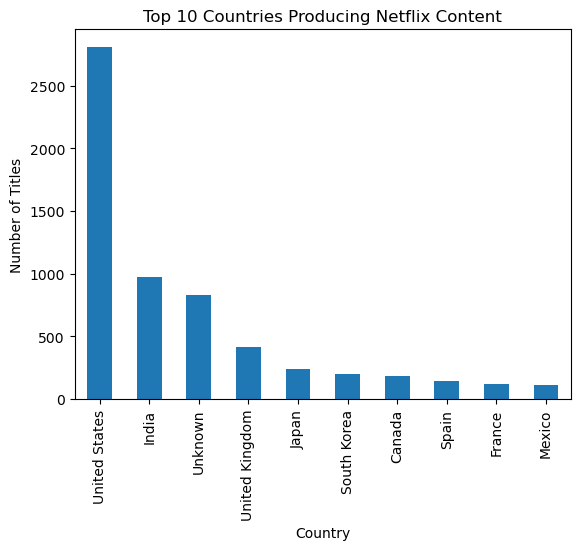

In [14]:
#Data Visualization
import matplotlib.pyplot as plt
top_countries = df['country'].value_counts().head(10)
top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

In [15]:
#Second visualization: Netflix content growth over years
#step 1 count titles released each year
year_counts = df["release_year"].value_counts().sort_index()
year_counts.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: count, dtype: int64

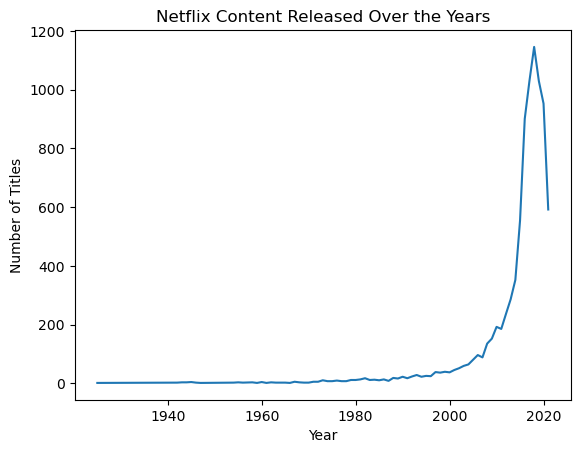

In [16]:
#step2 creates line chart
import matplotlib.pyplot as plt
plt.figure()

year_counts.plot(kind='line')

plt.title("Netflix Content Released Over the Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

In [17]:
#Netflix content production increased significantly after 2016, showing rapid expansion of the platform and investment in new content.

In [18]:
#3rd analysis does netflix have more movies or tv shows
#step1 count the types
type_counts = df['type'].value_counts()

type_counts

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

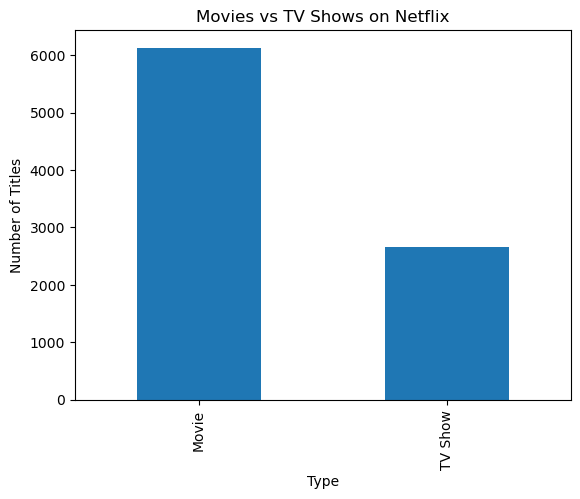

In [19]:
#step2 create bar chart
import matplotlib.pyplot as plt

type_counts.plot(kind='bar')

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")

plt.show()

In [20]:
#Netflix offers significantly more movies than TV shows, indicating that movies make up the majority of the platform's content library.

In [21]:
df['listed_in'].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

In [22]:
#step1 split the genres
genres = df["listed_in"].str.split(',')

In [23]:
#step2 expand the genres
genres = genres.explode()

In [24]:
#step 3 count genres
top_genres = genres.value_counts().head(10)
top_genres

listed_in
 International Movies     2624
Dramas                    1599
Comedies                  1210
Action & Adventure         859
Documentaries              829
 Dramas                    827
International TV Shows     773
 Independent Movies        736
 TV Dramas                 695
 Romantic Movies           613
Name: count, dtype: int64

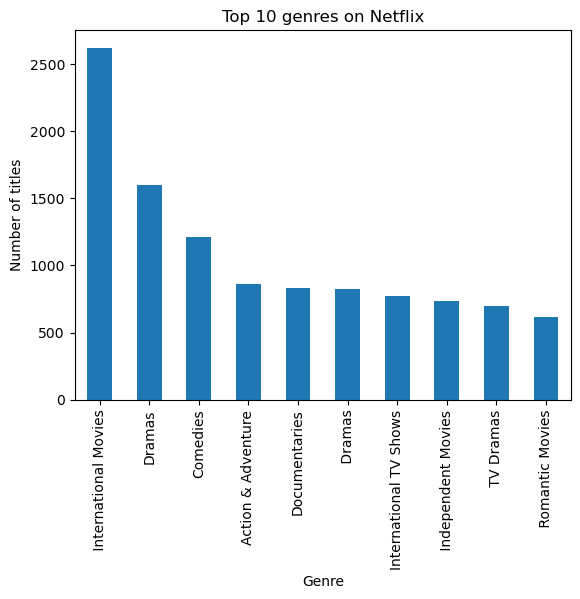

In [25]:
import matplotlib.pyplot as plt
top_genres.plot(kind = "bar")
plt.title("Top 10 genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of titles")
plt.show()

In [26]:
#International Movies and Dramas are among the most common genres on Netflix, indicating a strong focus on globally distributed content.

In [27]:
#Next Analysis: Top Directors on Netflix
#Which directors have produced the most content on Netflix?

In [28]:
#Step 1 — Split Directors
directors = df['director'].str.split(',') 

In [29]:
#step2 - expand the directors
directors = directors.explode()

directors = directors[directors != "Unknown"]

In [30]:
#step3 - find top directors
top_directors = directors.value_counts().head(10)
top_directors

director
Rajiv Chilaka          22
 Jan Suter             18
Raúl Campos            18
Marcus Raboy           16
Suhas Kadav            16
Jay Karas              15
Cathy Garcia-Molina    13
Martin Scorsese        12
Jay Chapman            12
Youssef Chahine        12
Name: count, dtype: int64

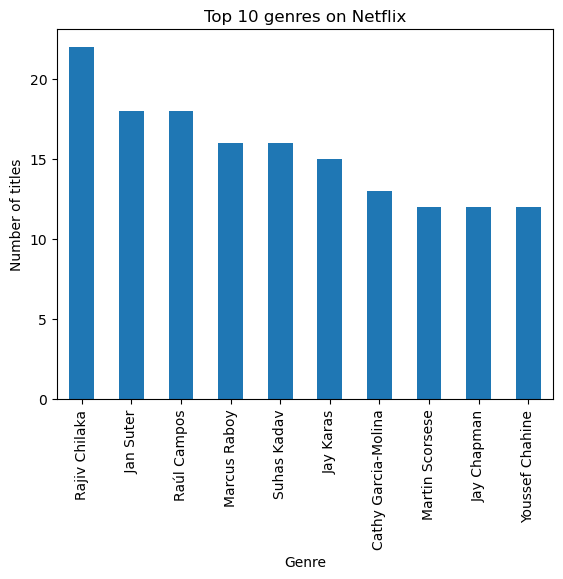

In [31]:
#step4 - visualization
import matplotlib.pyplot as plt
top_directors.plot(kind = "bar")
plt.title("Top 10 genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of titles")
plt.show()

In [32]:
#Rajiv Chilaka appears as one of the most frequent directors on Netflix, indicating strong collaboration with the platform, especially in animated and children's content.

In [33]:
# FINAL ANALYSIS: Content Added to Netflix Each Year
#This is one of the most important analyses because it shows how Netflix expanded its library over time.
#We will analyze the column:
#date_added

In [35]:
#Step1 - Clean the column
df['date_added'] = df['date_added'].str.strip()

In [36]:
#Step2 — Convert to Datetime
df['date_added'] = pd.to_datetime(df['date_added'])

In [38]:
#Step 3 — Extract Year
df['year_added'] = df['date_added'].dt.year

In [39]:
#Step 4 — Count Titles Per Year
content_per_year = df['year_added'].value_counts().sort_index()

content_per_year

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

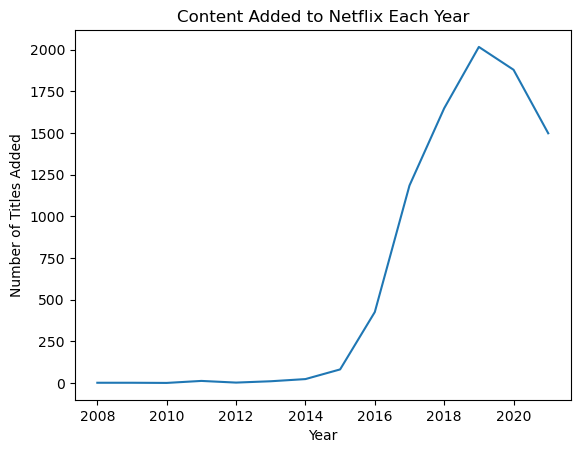

In [40]:
content_per_year.plot(kind='line')

plt.title("Content Added to Netflix Each Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.show()